Open the data from DataPart5.csv and model it using an ARMA model,
increasing the model order assisted by the ACF and PACF, until the residuals
look white. When you are reasonably satisfied compute the LDF of the
residuals. Do you find any significant non-linearities? Propose a better
model structure.

Hints Check the n-step residuals versus residuals plot, where n is the sig-
nificant LDF lag, i.e., et versus et−n.

R The script ldf.R is a way to estimate lagged dependent functions.

Matlab The script in ldf.m does an estimation of Lagged Dependent Func-
tions. The script in ldfone.m can be used to see the estimated dependence
function for some lag.

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import numpy as np

# Load data

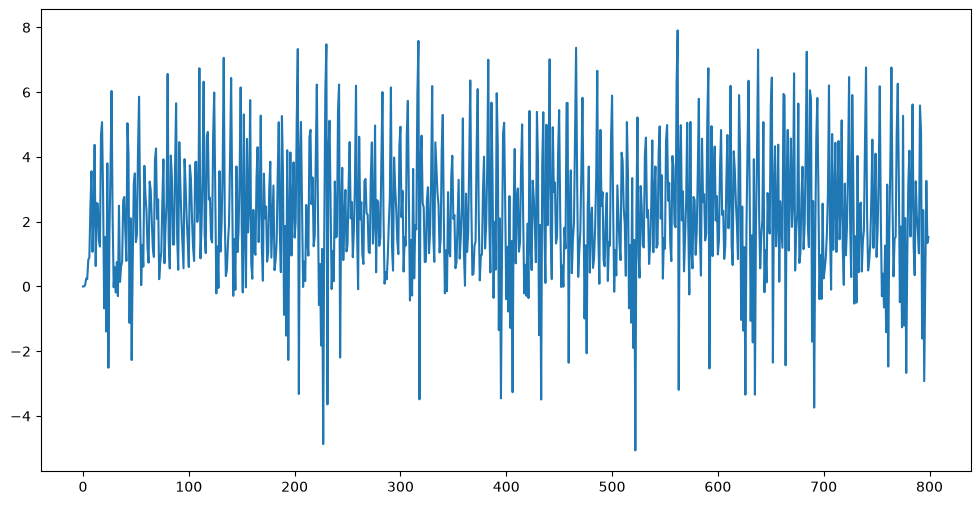

In [13]:
# Download data from csv file
data_path = '../data/'
# Load dataset to numpy
data = pd.read_csv(data_path + 'DataPart5.csv')
np_data = data['x'].to_numpy()

# Plot numpy data
plt.figure(figsize=(12, 6))
plt.plot(np_data)
plt.show()

# Model

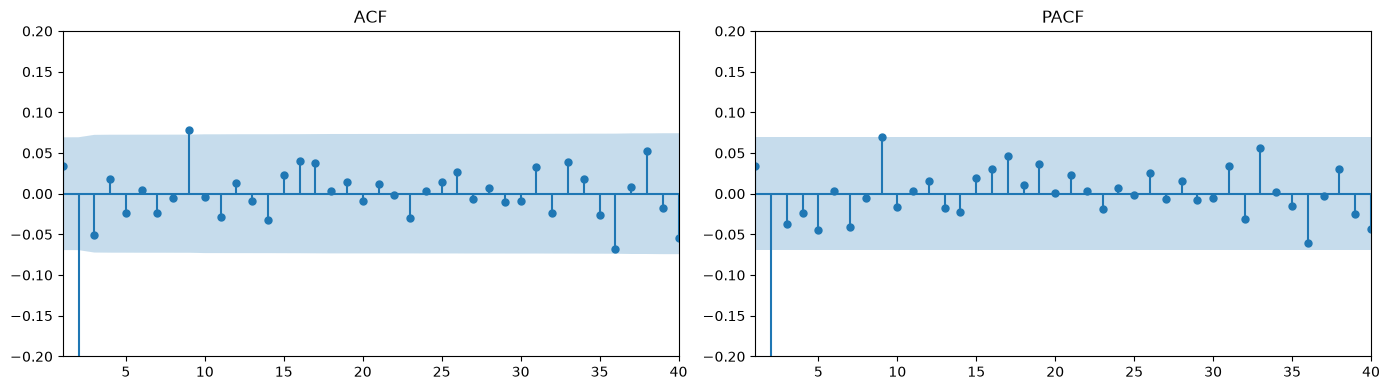

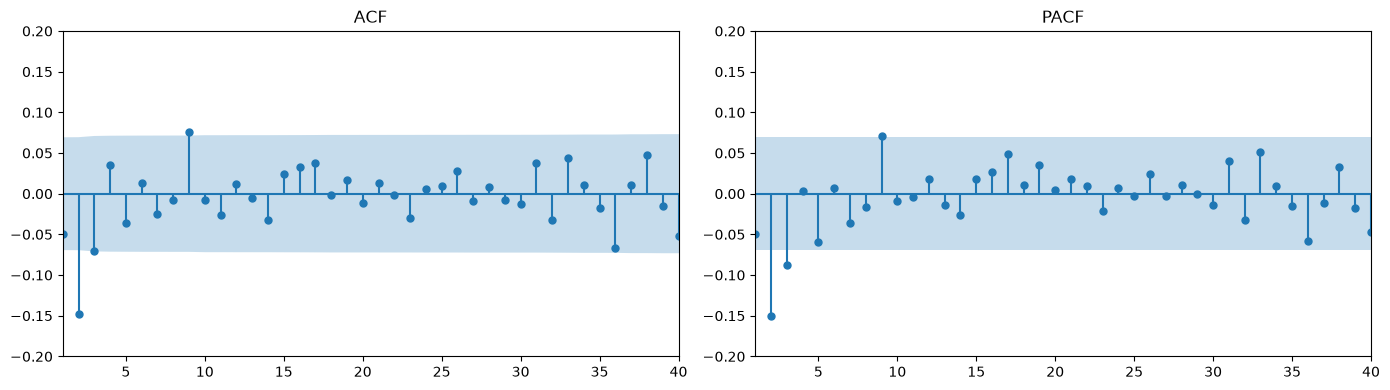

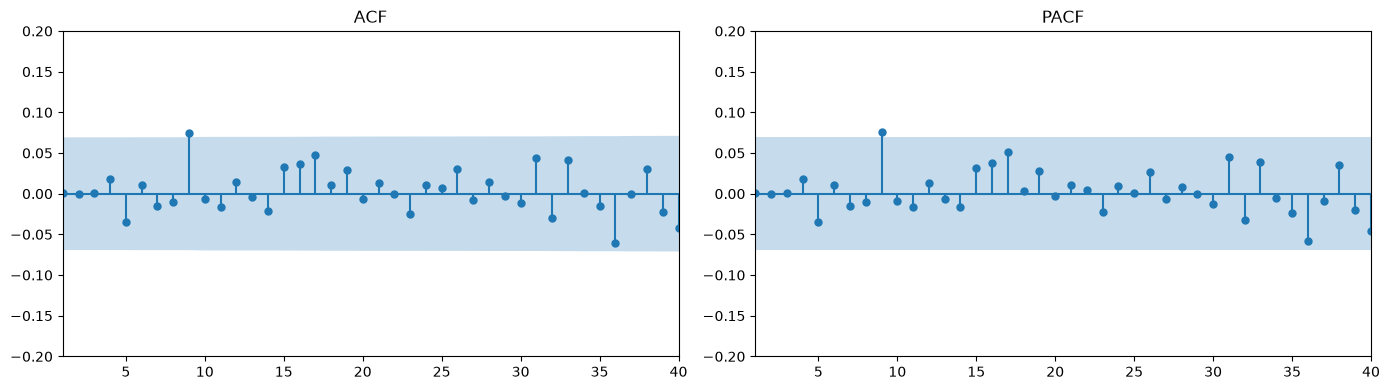

/home/husted42/Documents/github/webserver-linux/.venv/lib/python3.12/site-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


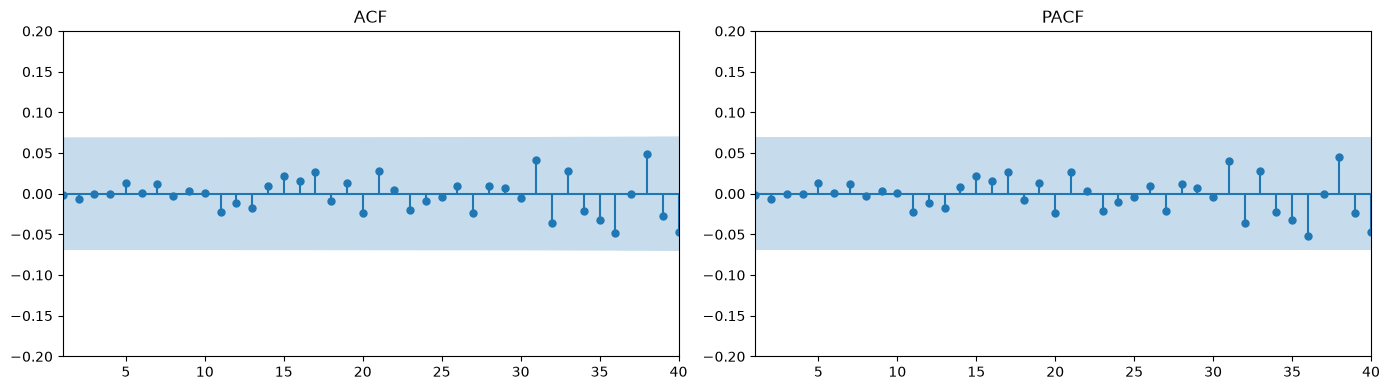

/home/husted42/Documents/github/webserver-linux/.venv/lib/python3.12/site-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/home/husted42/Documents/github/webserver-linux/.venv/lib/python3.12/site-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params


In [ ]:

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

def create_arma_model(data : np.ndarray, p: int, q: int):
    model = ARIMA(data, order=(p, 0, q))
    fitted_model = model.fit()
    return fitted_model


def plot_acf_pacf(data : np.ndarray, lags=40, y_limit = 0.2):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    plot_acf(data, lags=lags, ax=axes[0])
    plot_pacf(data, lags=lags, ax=axes[1], method='ywm')
    axes[0].set_xlim([1, lags])
    axes[1].set_xlim([1, lags])
    axes[0].set_ylim([-y_limit, y_limit])
    axes[1].set_ylim([-y_limit, y_limit])
    axes[0].set_title('ACF')
    axes[1].set_title('PACF')
    plt.tight_layout()
    plt.show()
    return fig, axes

# Original data
plot_acf_pacf(np_data, lags=40)

# First candidate
model_1 = create_arma_model(np_data, p=1, q=1)
residuals_1 = model_1.resid
plot_acf_pacf(residuals_1, lags=40)

# Second candidate
model_2 = create_arma_model(np_data, p=2, q=2)
residuals_2 = model_2.resid
plot_acf_pacf(residuals_2, lags=40)

# Third candidate, if needed
model_3 = create_arma_model(np_data, p=10, q=10)
residuals_3 = model_3.resid
plot_acf_pacf(residuals_3, lags=40)

# Third candidate, if needed
model_3 = create_arma_model(np_data, p=100, q=100)
residuals_3 = model_3.resid
plot_acf_pacf(residuals_3, lags=50)